In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
#import emcee

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import getdist
import IPython
from getdist import plots, MCSamples
from getdist import loadMCSamples

font = {'size'   : 15, 'family':'sans-serif'}
axislabelfontsize='large'
matplotlib.rc('font', **font)
matplotlib.rc('text', usetex=True)

np.infty = np.inf 

plt.rcParams["text.usetex"] = False  # Desactiva LaTeX externo

In [4]:
# Aqui, keys es como vamos a llamar a cada modelo en el codigo, 
# dirs el directorio de las cadenas, y legends lo que aparecera en las graficas
root_path = '/home/holman/HIIGalaxies/Bayesian_samplers/Cobaya/Lsigma/'
keys=['test'] 
list_of_dirs=['chains/cepheids_h0',
              ]
list_of_legends = ['fr'
                   ]
dirs=dict(zip(keys,list_of_dirs))
legends = dict(zip(keys,list_of_legends))

In [5]:
model_name = ['fr']

samples = {}
params = {}
for model in keys:
    if model != model_name:
        samples[model] = loadMCSamples(root_path + dirs[model],
                                       settings={'ignore_rows':0.3,'smooth_scale_2D':0.6,'smooth_scale_1D':0.6},
                                       no_cache=True)

        params[model] = samples[model].getParams()

        # Agregar parametros derivados comunes
        #samples[model].addDerived(params[model].sfdm_parameters__1, name='m_sfd', label=r'$m_{\phi}$')
        #samples[model].addDerived(params[model].Omega_sfdm_1, name='O_sfdm', label=r'$\Omega_{sfdm}$')
       
        samples[model].addDerived(params[model].H0, name='Hdot', label=r'$H_0$', range=[67.2,None])


/home/holman/HIIGalaxies/Bayesian_samplers/Cobaya/Lsigma/chains/cepheids_h0.1.txt
/home/holman/HIIGalaxies/Bayesian_samplers/Cobaya/Lsigma/chains/cepheids_h0.2.txt
/home/holman/HIIGalaxies/Bayesian_samplers/Cobaya/Lsigma/chains/cepheids_h0.3.txt
/home/holman/HIIGalaxies/Bayesian_samplers/Cobaya/Lsigma/chains/cepheids_h0.4.txt
/home/holman/HIIGalaxies/Bayesian_samplers/Cobaya/Lsigma/chains/cepheids_h0.5.txt
/home/holman/HIIGalaxies/Bayesian_samplers/Cobaya/Lsigma/chains/cepheids_h0.6.txt
/home/holman/HIIGalaxies/Bayesian_samplers/Cobaya/Lsigma/chains/cepheids_h0.7.txt
/home/holman/HIIGalaxies/Bayesian_samplers/Cobaya/Lsigma/chains/cepheids_h0.8.txt
Removed 0.3 as burn in


In [6]:
#Aqui escribo a una tabla
print(samples['test'].getTable(limit=1,paramList=['H0','omega_cdm','Omega_m',
                                                  'n_s', 'Omega_Lambda']).tableTex())

\begin{tabular} { l  c}

 Parameter &  68\% limits\\
\hline
{\boldmath$H_0            $} & $72.3\pm 2.7               $\\

$\Omega_m                  $ & $0.273\pm 0.021            $\\
\hline
\end{tabular}


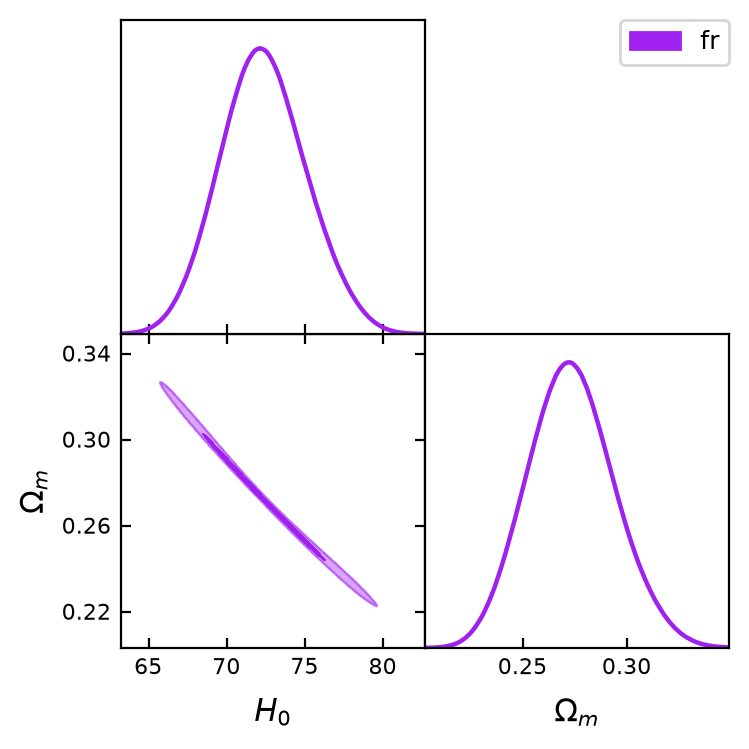

In [8]:
g = plots.get_subplot_plotter()
#g.set_legend(param1,param2)
subkey=['test']
subsample=[samples[model] for model in subkey]
sublegend = [legends[model] for model in subkey]
g.triangle_plot(subsample,['H0', 'Omega_m'],colored_text=True
                ,filled=True, shaded=False,legend_labels=sublegend,
               contour_colors=['#A020F0'],contour_lws=1.6)
plt.savefig('test.pdf')

In [12]:
print(samples['test'].getLikeStats())

Best fit sample -log(Like) = 1415.972500
Ln(mean 1/like) = 1435.111655
mean(-Ln(like)) = 1426.297692
-Ln(mean like)  = 1422.309484
2*Var(Ln(like)) = 25.619781

parameter                             bestfit        lower1         upper1         lower2         upper2
logA                                  3.0539672E+00  3.0033882E+00  3.1013586E+00  3.0028803E+00  3.1047647E+00   \log(10^{10} A_\mathrm{s})
n_s                                   9.7172601E-01  9.5852345E-01  9.8127132E-01  9.5802272E-01  9.8259859E-01   n_\mathrm{s}
theta_s_100                           1.0420549E+00  1.0412083E+00  1.0429821E+00  1.0410411E+00  1.0430861E+00   100\theta_\mathrm{s}
omega_b                               2.2569250E-02  2.2101644E-02  2.2959617E-02  2.2101644E-02  2.3006176E-02   \Omega_\mathrm{b} h^2
omega_cdm                             1.1777250E-01  1.1564418E-01  1.2019443E-01  1.1536526E-01  1.2029609E-01   \Omega_\mathrm{c} h^2
tau_reio                              6.2019426E-02  3.33860